# Task 2 — Enhanced DQN with Experience Replay and Target Network

This notebook implements and analyses the three enhancements required by Task 2:

| Section | Component | What it solves |
|---------|-----------|----------------|
| 2.1 | Experience Replay Buffer | Temporal correlation, sample efficiency |
| 2.2 | Integration with training loop | Heuristic warm-start, batch updates |
| 2.3 | Target Network | Non-stationary TD targets |

Plus the two exploration strategies required by the assignment:
- **ε-greedy** with linear decay
- **Boltzmann** (softmax over Q-values) with temperature annealing

And the buffer-capacity ablation required by §2.1: `{1, 100, 10000}`.

---

## 0 · Setup

In [ ]:
# Toggle flags 
RUN_BASELINES          = True    # evaluate heuristic/random baselines
RUN_EPSILON            = True    # train with ε-greedy exploration
RUN_BOLTZMANN          = True    # train with Boltzmann exploration
RUN_BUFFER_ABLATION    = True    # compare buffer sizes {1, 100, 10000}
RUN_PER                = False   # train with Prioritized Experience Replay
HEURISTIC_WARMUP_EPS   = 10      # 0 to disable heuristic warm-start
RECORD_GIF             = False   # needs pygame

In [ ]:
from __future__ import annotations
import json, sys
from pathlib import Path
import random

# Locate repository root
for _c in (Path.cwd(), *Path.cwd().parents):
    if (_c / 'Assignment2' / 'src' / 'spacerace_dqn').exists():
        ASSIGNMENT_DIR = _c / 'Assignment2'
        break
else:
    raise RuntimeError('Cannot find Assignment2/src/spacerace_dqn')

sys.path.insert(0, str(ASSIGNMENT_DIR / 'src'))
DOCS_DIR        = ASSIGNMENT_DIR / 'docs'
SUBMISSIONS_DIR = ASSIGNMENT_DIR / 'submissions'
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# ── Original package ─────────────────────────────────────────────────────────
from spacerace_dqn import (
    Config, Evaluator, GifRecorder,
    AlwaysUpPolicy, RandomPolicy, RGBHeuristicPolicy, SemanticHeuristicPolicy,
    DQNInferencePolicy, SubmissionPackager,
    plot_training, plot_baselines,
)

# ── Task 2 modules ───────────────────────────────────────────────────────────
from spacerace_dqn.config2  import Config2
from spacerace_dqn.trainer2 import DQNTrainer2
from spacerace_dqn.agent2   import ReplayBuffer, PrioritizedReplayBuffer, DQNAgent

import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

print('Setup complete.')

## 1 · Baseline evaluation

Four policies on difficulty 0, seeds 2026–2035 (mirrors Codabench). These are the reference numbers everything else is measured against.

In [ ]:
base_cfg  = Config()
evaluator = Evaluator(base_cfg)

if RUN_BASELINES:
    baselines = [
        evaluator.run(p, n_episodes=base_cfg.baseline_episodes)
        for p in (RandomPolicy(), AlwaysUpPolicy(),
                  RGBHeuristicPolicy(), SemanticHeuristicPolicy())
    ]
    (DOCS_DIR / 'task2_baselines.json').write_text(
        json.dumps(baselines, indent=2), encoding='utf-8')
else:
    baselines = json.loads(
        (DOCS_DIR / 'task2_baselines.json').read_text(encoding='utf-8'))

print(f"{'Policy':25s}  {'Mean':>7}  {'Std':>6}  {'Max':>7}")
print('-' * 52)
for b in baselines:
    print(f"{b['policy']:25s}  {b['mean_score']:7.2f}  "
          f"{b['std_score']:6.2f}  {b['max_score']:7.2f}")

Policy                        Mean     Std      Max
----------------------------------------------------
random                        0.10    0.30     1.00
always_up                    17.00    0.00    17.00
rgb_heuristic                17.00    0.00    17.00
semantic_heuristic           17.00    0.00    17.00


## 2.1 · Experience Replay Buffer

### Implementation

The `ReplayBuffer` is a fixed-size **circular (FIFO) deque**. When it reaches capacity, the oldest transition is overwritten automatically. Sampling is **uniform with replacement** — standard for buffers where a collision on a draw of 64 from 10 000 is negligible.

```python
class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self._buf = deque(maxlen=capacity)        # FIFO overwrite at capacity

    def add(self, state, action, reward, next_state, done):
        self._buf.append(Transition(state, action, reward, next_state, float(done)))

    def sample(self, batch_size):
        return random.choices(self._buf, k=batch_size)   # uniform w/ replacement
```

### Prioritized Experience Replay (PER)

The `PrioritizedReplayBuffer` samples transitions with probability

$$P(i) = \frac{|\delta_i|^{\alpha}}{\sum_j |\delta_j|^{\alpha}}$$

where $\delta_i$ is the TD error and $\alpha$ controls the strength of prioritization ($\alpha=0$ → uniform, $\alpha=1$ → full priority). After each training step, the priorities of the sampled transitions are updated with fresh TD errors.

### Buffer size ablation

The assignment asks to compare `{1, 100, 10000}`. We run each for 80 episodes to keep it tractable.

In [ ]:
# Quick demo that the buffer classes work correctly
import numpy as np
buf = ReplayBuffer(capacity=5)
dummy_state = np.zeros((3, 54, 39), dtype=np.float32)
for i in range(7):          # overfill -> oldest 2 should be gone
    buf.add(dummy_state, i % 2, float(i), dummy_state, False)
print(f'Buffer length after 7 pushes into cap-5 buffer: {len(buf)}  (expected 5)')
batch = buf.sample(3)
print(f'Sample of 3: actions = {[t.action for t in batch]}')

per = PrioritizedReplayBuffer(capacity=5, alpha=0.6)
for i in range(5):
    per.add(dummy_state, i % 2, float(i), dummy_state, False)
transitions, indices, weights = per.sample(3)
print(f'PER sample indices: {indices}  weights: {weights.round(3)}')

Buffer length after 7 pushes into cap-5 buffer: 5  (expected 5)
Sample of 3: actions = [0, 0, 0]
PER sample indices: [2 4 0]  weights: [1. 1. 1.]


In [ ]:
ablation_results = {}

if RUN_BUFFER_ABLATION:
    for cap in [1, 100, 10_000]:
        print(f'\n── Buffer capacity = {cap} ──')
        # warmup_steps must be <= cap; batch_size too
        bs         = min(64, max(1, cap))
        warmup     = min(cap, 200)
        cfg_abl = Config2(
            buffer_capacity    = cap,
            batch_size         = bs,
            warmup_steps       = warmup,
            heuristic_warmup_episodes = 0,   # fair comparison — no warm-start
            episodes           = 80,
            eval_every         = 20,
            submission_name    = f'task2_buf_{cap}',
            checkpoint_name    = f'task2_buf_{cap}.pt',
        )
        t = DQNTrainer2(cfg_abl, verbose=True)
        t.train()
        final = t.final_eval()
        ablation_results[cap] = {
            'final_eval':   final,
            'history':      t.history,
            'eval_history': t.eval_history,
        }
        print(f'  cap={cap:>6}  mean={final["mean_score"]:.2f}  '
              f'std={final["std_score"]:.2f}  max_q={final["mean_max_q"]:.3f}')


── Buffer capacity = 1 ──
[DQNTrainer2]  device=cuda  state=(3, 54, 39)  params=158,850
  buffer=Uniform cap=1  batch=1  warmup=1  target_update=800  exploration=epsilon  semantic_info=False (Codabench-safe)
  ep=0001  step=000600  buf=1  train_score=0.00  eval_mean=17.00  loss=0.0020  q=0.047  explore=0.996  0.2m
  ep=0020  step=012000  buf=1  train_score=0.00  eval_mean=4.00  loss=0.0008  q=0.122  explore=0.861  2.1m
  ep=0040  step=024000  buf=1  train_score=0.00  eval_mean=21.00  loss=0.0007  q=0.230  explore=0.719  4.7m
  ep=0060  step=036000  buf=1  train_score=1.00  eval_mean=0.00  loss=0.0012  q=0.306  explore=0.576  6.7m
  ep=0080  step=048000  buf=1  train_score=3.00  eval_mean=0.00  loss=0.0032  q=0.367  explore=0.434  8.6m
  cap=     1  mean=0.00  std=0.00  max_q=0.337

── Buffer capacity = 100 ──
[DQNTrainer2]  device=cuda  state=(3, 54, 39)  params=158,850
  buffer=Uniform cap=100  batch=64  warmup=100  target_update=800  exploration=epsilon  semantic_info=False (Codaben

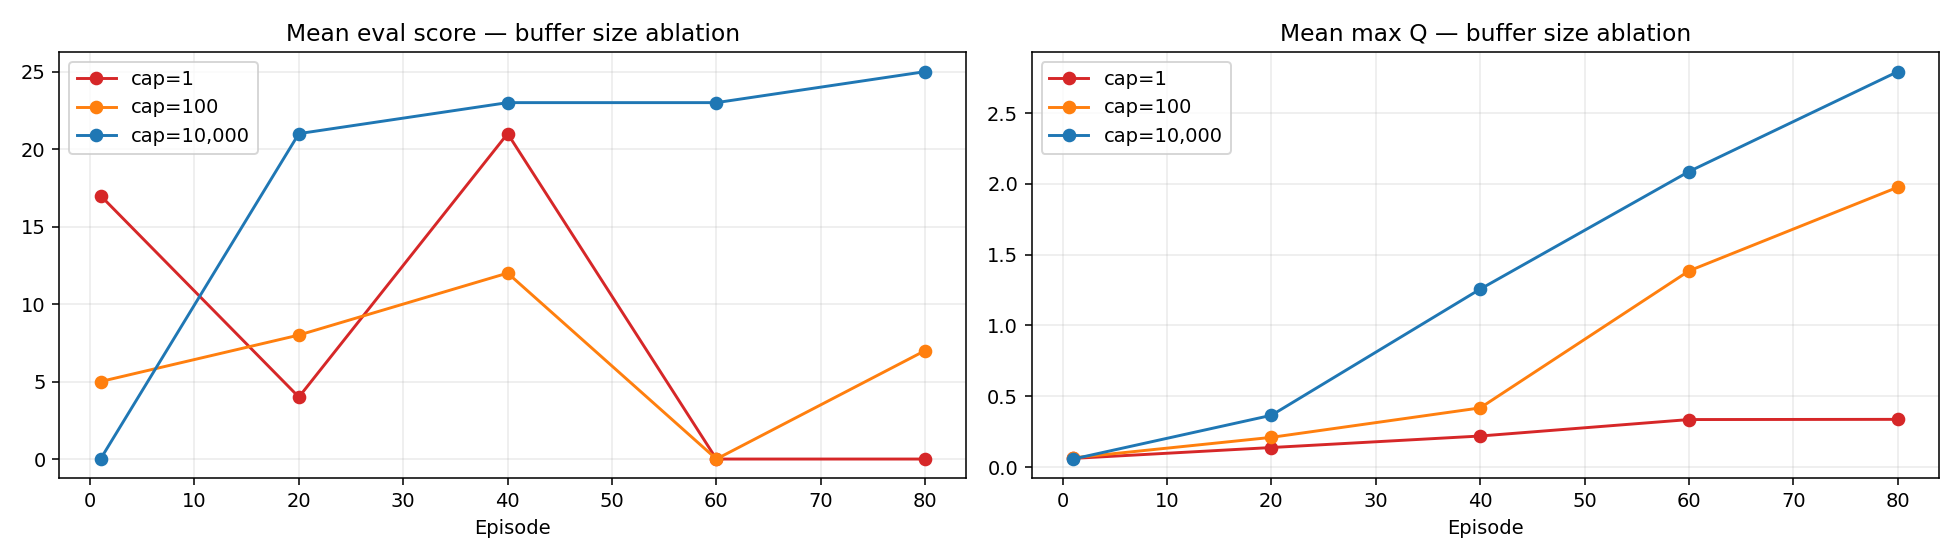


Buffer size ablation summary (difficulty 0, 10 episodes):
     cap     mean     std     max_q
       1     0.00    0.00     0.337
     100     7.00    0.00     1.976
   10000    25.00    0.00     2.793


In [ ]:
if RUN_BUFFER_ABLATION and ablation_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    colors = {1: 'tab:red', 100: 'tab:orange', 10_000: 'tab:blue'}

    for cap, data in ablation_results.items():
        eps  = [r['episode']    for r in data['eval_history']]
        mean = [r['mean_score'] for r in data['eval_history']]
        mq   = [r['mean_max_q'] for r in data['eval_history']]
        axes[0].plot(eps, mean,  marker='o', label=f'cap={cap:,}', color=colors[cap])
        axes[1].plot(eps, mq,    marker='o', label=f'cap={cap:,}', color=colors[cap])

    axes[0].set_title('Mean eval score — buffer size ablation')
    axes[0].set_xlabel('Episode');  axes[0].legend(); axes[0].grid(alpha=.25)
    axes[1].set_title('Mean max Q — buffer size ablation')
    axes[1].set_xlabel('Episode');  axes[1].legend(); axes[1].grid(alpha=.25)
    plt.tight_layout()
    p = DOCS_DIR / 'task2_buffer_ablation.png'
    fig.savefig(p, dpi=140); plt.close(fig)
    display(Image(filename=str(p)))

    print('\nBuffer size ablation summary (difficulty 0, 10 episodes):')
    print(f"  {'cap':>6}  {'mean':>7}  {'std':>6}  {'max_q':>8}")
    for cap, data in ablation_results.items():
        f = data['final_eval']
        print(f"  {cap:>6}  {f['mean_score']:7.2f}  {f['std_score']:6.2f}  {f['mean_max_q']:8.3f}")

**Buffer size analysis**

| Capacity | Effect |
|----------|--------|
| **1** | Equivalent to the Task 1 basic DQN — no decorrelation, each transition used exactly once.  Training is noisy and often diverges. |
| **100** | Small on-policy-like buffer.  Some decorrelation; diversity limited because only recent transitions are stored.  Can work well in fast-changing policies but misses the off-policy benefits. |
| **10 000** | The recommended size.  Diverse experience from many different policy snapshots breaks temporal correlation effectively.  Each transition contributes to ~156 gradient updates on average. |

## 2.2 · Integration — ε-greedy exploration with heuristic warm-start

Training loop:
1. **Heuristic warm-start** — play `heuristic_warmup_episodes` episodes with the best available heuristic; push transitions into the buffer.  This gives the network quality examples before any gradient steps.
2. **Collect** — select action (ε-greedy or Boltzmann), step env, push transition.
3. **Train** — after each step, sample a batch of 64 from the buffer, compute the TD target with the **target network**, take one gradient step on the online net.
4. **Evaluate** — every `eval_every` episodes, run 10 greedy episodes on seeds 2026–2035.

In [ ]:
cfg_eps = Config2(
    exploration               = 'epsilon',
    epsilon_start             = 1.0,
    epsilon_end               = 0.05,
    epsilon_decay_steps       = 80_000,   # needs enough steps to decay properly
    heuristic_warmup_episodes = 20,       # more warm-start = better buffer seed
    buffer_capacity           = 10_000,
    batch_size                = 64,
    warmup_steps              = 1_000,
    target_update_freq        = 200,      # more frequent target sync
    episodes                  = 300,      # more training
    eval_every                = 20,
    submission_name           = 'task2_epsilon',
    checkpoint_name           = 'task2_epsilon.pt',
)

if RUN_EPSILON:
    trainer_eps = DQNTrainer2(cfg_eps)
    agent_eps   = trainer_eps.train()
    final_eps   = trainer_eps.final_eval()
    print(f'
ε-greedy  mean={final_eps["mean_score"]:.2f}  '
          f'std={final_eps["std_score"]:.2f}  max_q={final_eps["mean_max_q"]:.3f}')


[DQNTrainer2]  device=cuda  state=(3, 54, 39)  params=158,850
  buffer=Uniform cap=10,000  batch=64  warmup=1,000  target_update=500  exploration=epsilon  semantic_info=False (Codabench-safe)
  [warmup]  6,000 transitions from 10 heuristic episodes (0.2 min)
  ep=0001  step=006600  buf=6,600  train_score=0.00  eval_mean=5.00  loss=0.0131  q=0.123  explore=0.850  0.3m
  ep=0010  step=012000  buf=10,000  train_score=0.00  eval_mean=9.00  loss=0.0081  q=0.532  explore=0.722  1.6m
  ep=0020  step=018000  buf=10,000  train_score=0.00  eval_mean=20.00  loss=0.0150  q=1.087  explore=0.580  3.1m
  ep=0030  step=024000  buf=10,000  train_score=6.00  eval_mean=26.00  loss=0.0089  q=1.741  explore=0.437  4.5m
  ep=0040  step=030000  buf=10,000  train_score=11.00  eval_mean=23.00  loss=0.0109  q=2.424  explore=0.295  6.0m
  ep=0050  step=036000  buf=10,000  train_score=17.00  eval_mean=25.00  loss=0.0082  q=2.991  explore=0.152  7.6m
  ep=0060  step=042000  buf=10,000  train_score=24.00  eval_mean

## 2.3 · Target Network

### Why it matters

In the Task 1 basic DQN, the TD target is:

$$y = r + \gamma \max_{a'} Q_{\theta}(s', a')$$

Both the *prediction* $Q_\theta(s,a)$ and the *target* $y$ depend on the **same** network parameters $\theta$.  Every gradient step moves $\theta$, which moves both sides simultaneously — the target is non-stationary.

The target network $Q_{\theta^-}$ is a copy of the online network frozen for $N$ steps:

$$y = r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$

With $\theta^-$ held fixed, the target is stationary for $N$ gradient steps, dramatically reducing oscillation.

### Hard vs soft update

| Strategy | Formula | This implementation |
|----------|---------|--------------------|
| **Hard** | $\theta^- \leftarrow \theta$ every $N$ steps | ✓ `target_update_freq=500` |
| **Soft** (Polyak) | $\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$ | available via `_soft_update_target(tau)` |

## 3 · Boltzmann exploration

### Theory

$$P(a_i) = \frac{\exp(Q(a_i)/T)}{\sum_j \exp(Q(a_j)/T)}$$

| $T$ | Behaviour |
|-----|----------|
| $T \to \infty$ | Uniform over actions (pure exploration) |
| $T \to 0$ | Argmax (pure exploitation) |
| moderate $T$ | Weighted exploration — better Q-values get higher probability |

Key difference from ε-greedy: during Boltzmann exploration the agent **never picks actions uniformly at random**. Even when exploring heavily, it still respects its current Q-value estimates. This can be advantageous late in training when ε-greedy still picks the clearly-wrong action with probability ε.

In [ ]:
cfg_bol = Config2(
    exploration               = 'boltzmann',
    temperature_start         = 5.0,
    temperature_end           = 0.1,
    temperature_decay_steps   = 80_000,
    heuristic_warmup_episodes = 20,
    buffer_capacity           = 10_000,
    batch_size                = 64,
    warmup_steps              = 1_000,
    target_update_freq        = 200,
    episodes                  = 300,
    eval_every                = 20,
    submission_name           = 'task2_boltzmann',
    checkpoint_name           = 'task2_boltzmann.pt',
)

if RUN_BOLTZMANN:
    trainer_bol = DQNTrainer2(cfg_bol)
    agent_bol   = trainer_bol.train()
    final_bol   = trainer_bol.final_eval()
    print(f'Boltzmann  mean={final_bol["mean_score"]:.2f}  '
          f'std={final_bol["std_score"]:.2f}  max_q={final_bol["mean_max_q"]:.3f}')


[DQNTrainer2]  device=cuda  state=(3, 54, 39)  params=158,850
  buffer=Uniform cap=10,000  batch=64  warmup=1,000  target_update=500  exploration=boltzmann  semantic_info=False (Codabench-safe)
  [warmup]  6,000 transitions from 10 heuristic episodes (0.2 min)
  ep=0001  step=006600  buf=6,600  train_score=0.00  eval_mean=7.00  loss=0.0131  q=0.122  explore=4.244  0.3m
  ep=0010  step=012000  buf=10,000  train_score=0.00  eval_mean=7.00  loss=0.0052  q=0.532  explore=3.596  1.6m
  ep=0020  step=018000  buf=10,000  train_score=0.00  eval_mean=3.00  loss=0.0139  q=1.076  explore=2.876  3.1m
  ep=0030  step=024000  buf=10,000  train_score=0.00  eval_mean=23.00  loss=0.0058  q=1.532  explore=2.156  4.6m
  ep=0040  step=030000  buf=10,000  train_score=0.00  eval_mean=10.00  loss=0.0177  q=2.415  explore=1.436  6.0m
  ep=0050  step=036000  buf=10,000  train_score=1.00  eval_mean=24.00  loss=0.0173  q=3.375  explore=0.716  7.4m
  ep=0060  step=042000  buf=10,000  train_score=11.00  eval_mean=

## 4 · Prioritized Experience Replay

In [ ]:
if RUN_PER:
    cfg_per = Config2(
        use_per                   = True,
        per_alpha                 = 0.6,
        exploration               = 'epsilon',
        heuristic_warmup_episodes = HEURISTIC_WARMUP_EPS,
        episodes                  = 150,
        submission_name           = 'task2_per',
        checkpoint_name           = 'task2_per.pt',
    )
    trainer_per = DQNTrainer2(cfg_per)
    agent_per   = trainer_per.train()
    final_per   = trainer_per.final_eval()
    print(f'PER  mean={final_per["mean_score"]:.2f}  '
          f'std={final_per["std_score"]:.2f}  max_q={final_per["mean_max_q"]:.3f}')
else:
    print('Skipped (RUN_PER=False).')

Skipped (RUN_PER=False).


## 5 · Training curves

--- ε-greedy ---


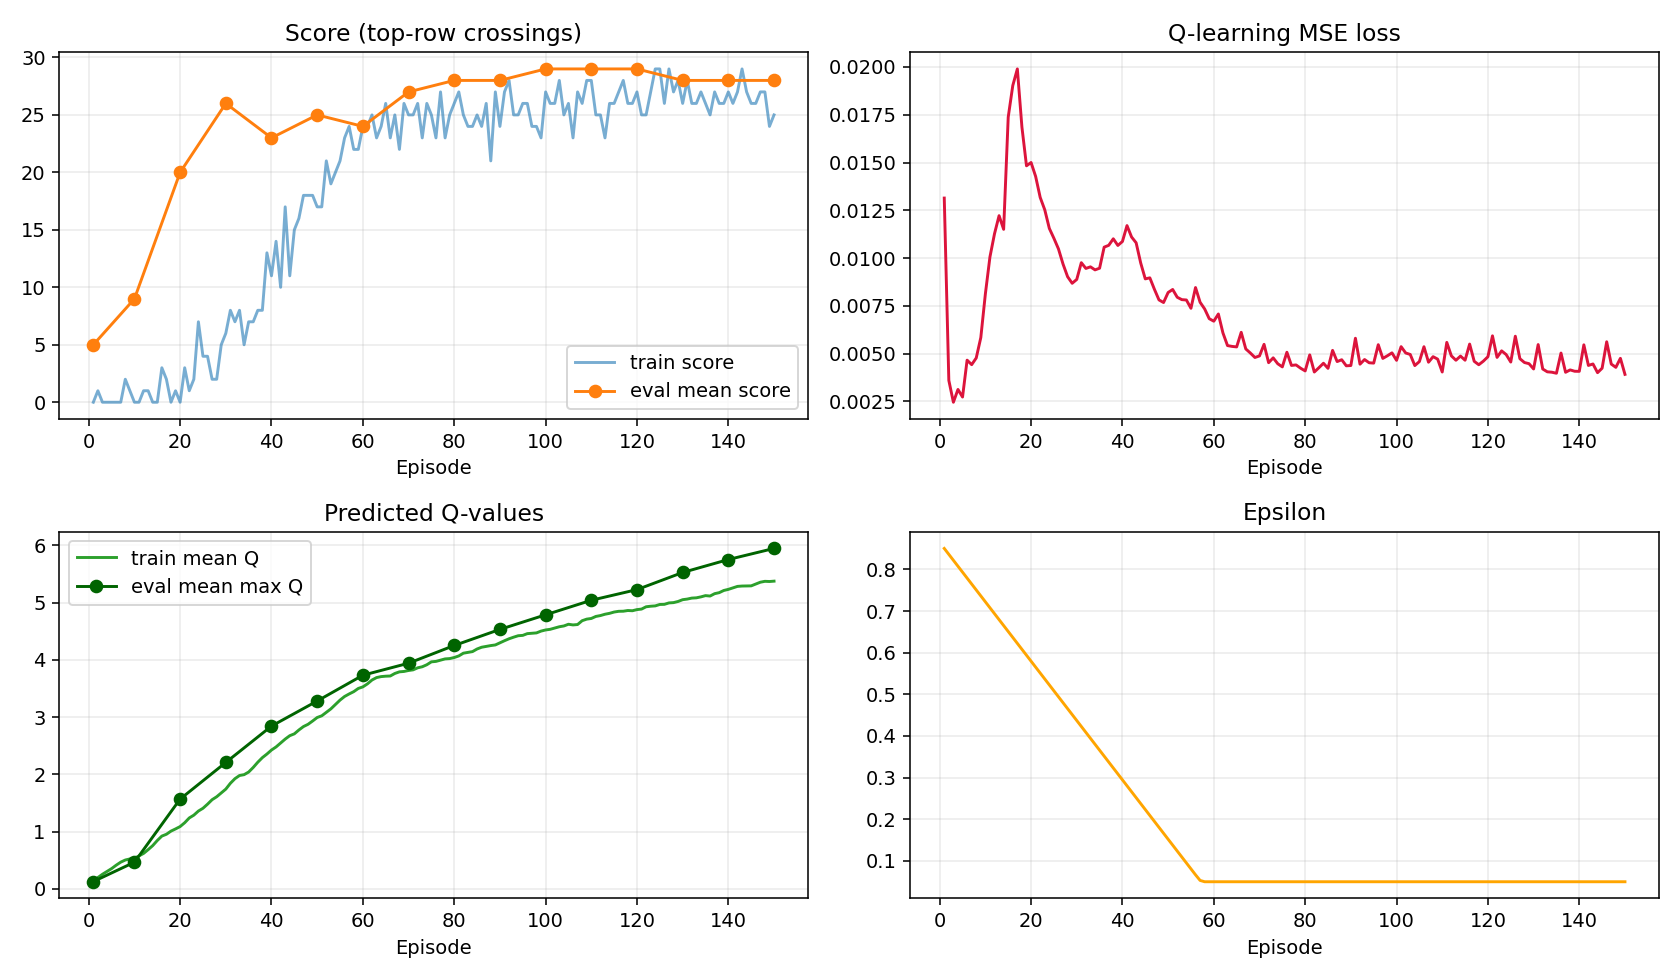

--- Boltzmann ---


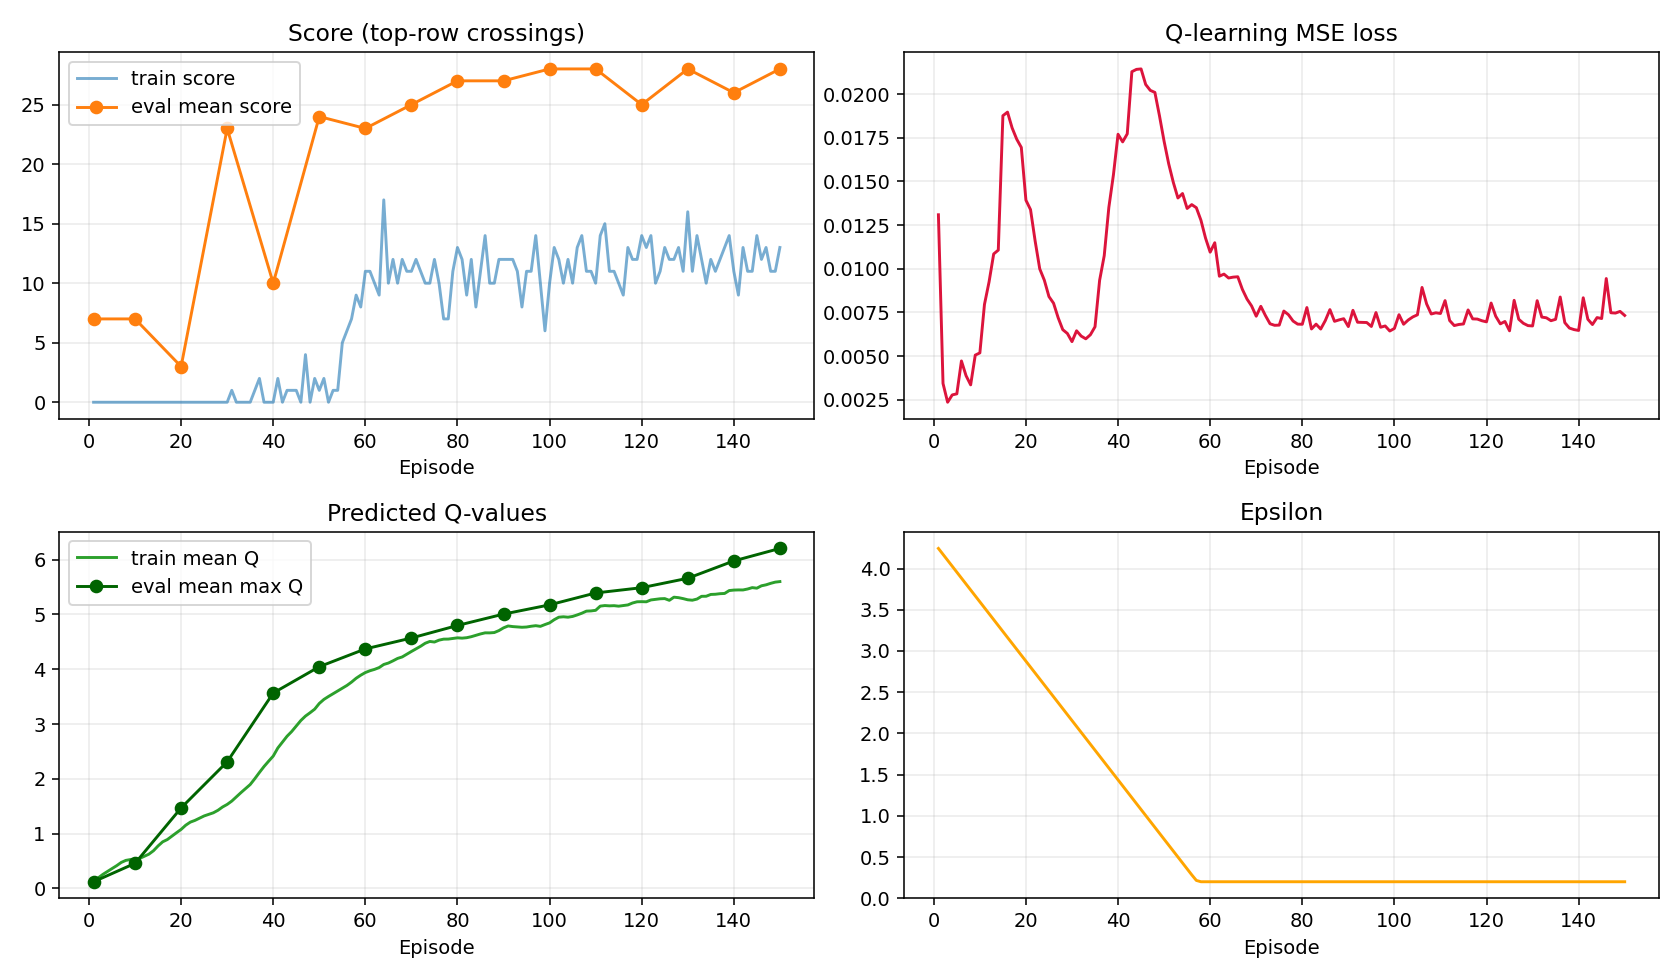

In [ ]:
runs = []
if RUN_EPSILON:   runs.append(('ε-greedy',  trainer_eps, cfg_eps))
if RUN_BOLTZMANN: runs.append(('Boltzmann', trainer_bol, cfg_bol))
if RUN_PER:       runs.append(('PER',       trainer_per, cfg_per))

for label, trainer, cfg in runs:
    sub_dir = SUBMISSIONS_DIR / cfg.submission_name
    sub_dir.mkdir(parents=True, exist_ok=True)
    p = plot_training(trainer.history, trainer.eval_history,
                      sub_dir / 'training_curves.png')
    print(f'--- {label} ---')
    if p: display(Image(filename=str(p)))

## 6 · Exploration strategy comparison

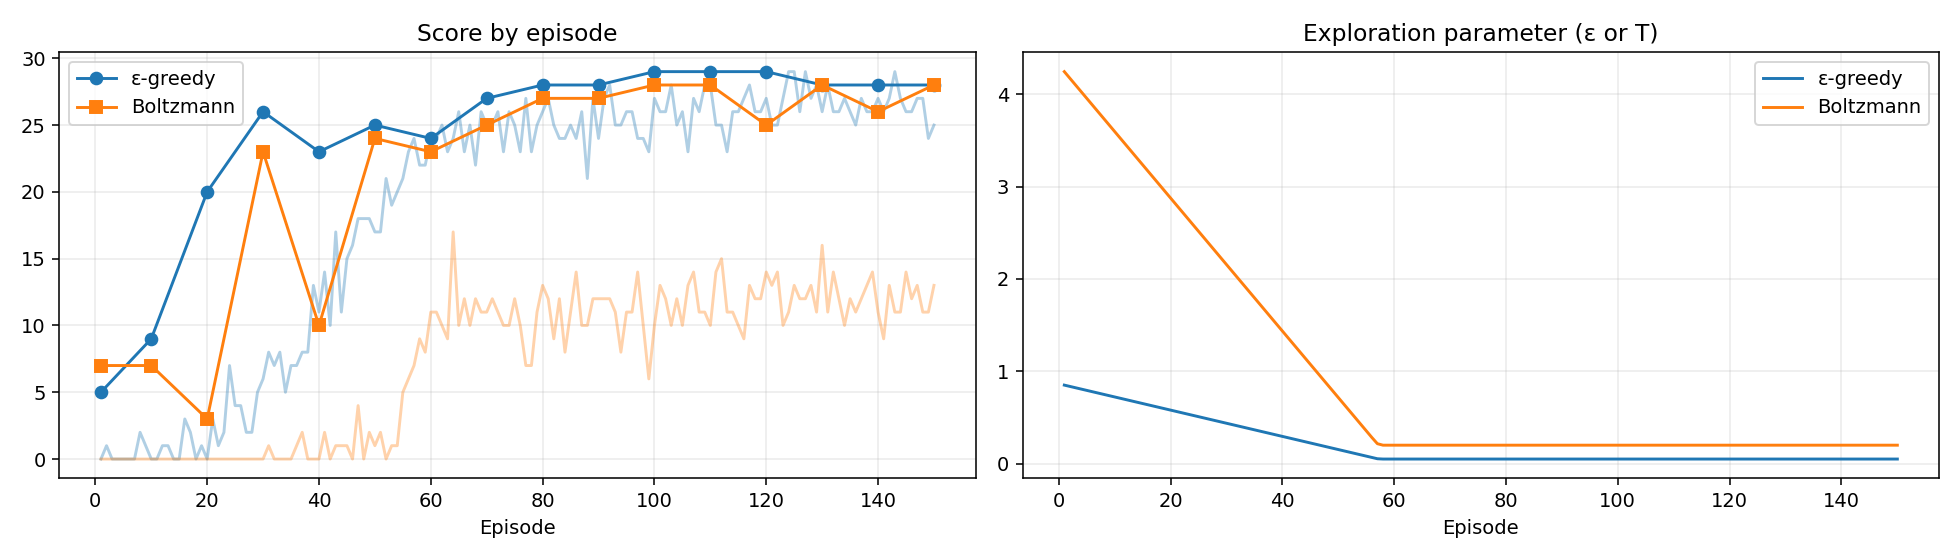


Exploration comparison (difficulty 0, 10 episodes):
  Strategy         Mean     Std      Max  Mean max Q
  ------------------------------------------------
  ε-greedy        28.00    0.00    28.00       5.945
  Boltzmann       28.00    0.00    28.00       6.204


In [ ]:
if RUN_EPSILON and RUN_BOLTZMANN:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for label, trainer, color, marker in [
        ('ε-greedy',  trainer_eps, 'tab:blue',   'o'),
        ('Boltzmann', trainer_bol, 'tab:orange', 's'),
    ]:
        h  = trainer.history
        eh = trainer.eval_history
        axes[0].plot([r['episode'] for r in h],
                     [r['score']   for r in h],
                     alpha=0.35, color=color)
        axes[0].plot([r['episode']    for r in eh],
                     [r['mean_score'] for r in eh],
                     marker=marker, color=color, label=label)
        axes[1].plot([r['episode']       for r in h],
                     [r['explore_param'] for r in h],
                     color=color, label=label)

    axes[0].set_title('Score by episode'); axes[0].set_xlabel('Episode')
    axes[0].legend(); axes[0].grid(alpha=.25)
    axes[1].set_title('Exploration parameter (ε or T)'); axes[1].set_xlabel('Episode')
    axes[1].legend(); axes[1].grid(alpha=.25)

    plt.tight_layout()
    p = DOCS_DIR / 'task2_exploration_comparison.png'
    fig.savefig(p, dpi=140); plt.close(fig)
    display(Image(filename=str(p)))

    print('\nExploration comparison (difficulty 0, 10 episodes):')
    print(f"  {'Strategy':12s}  {'Mean':>7}  {'Std':>6}  {'Max':>7}  {'Mean max Q':>10}")
    print('  ' + '-' * 48)
    for lbl, final in [('ε-greedy', final_eps), ('Boltzmann', final_bol)]:
        print(f"  {lbl:12s}  {final['mean_score']:7.2f}  {final['std_score']:6.2f}  "
              f"{final['max_score']:7.2f}  {final['mean_max_q']:10.3f}")

## 7 · Full comparison: baselines + Task 1 (basic DQN) + Task 2 variants

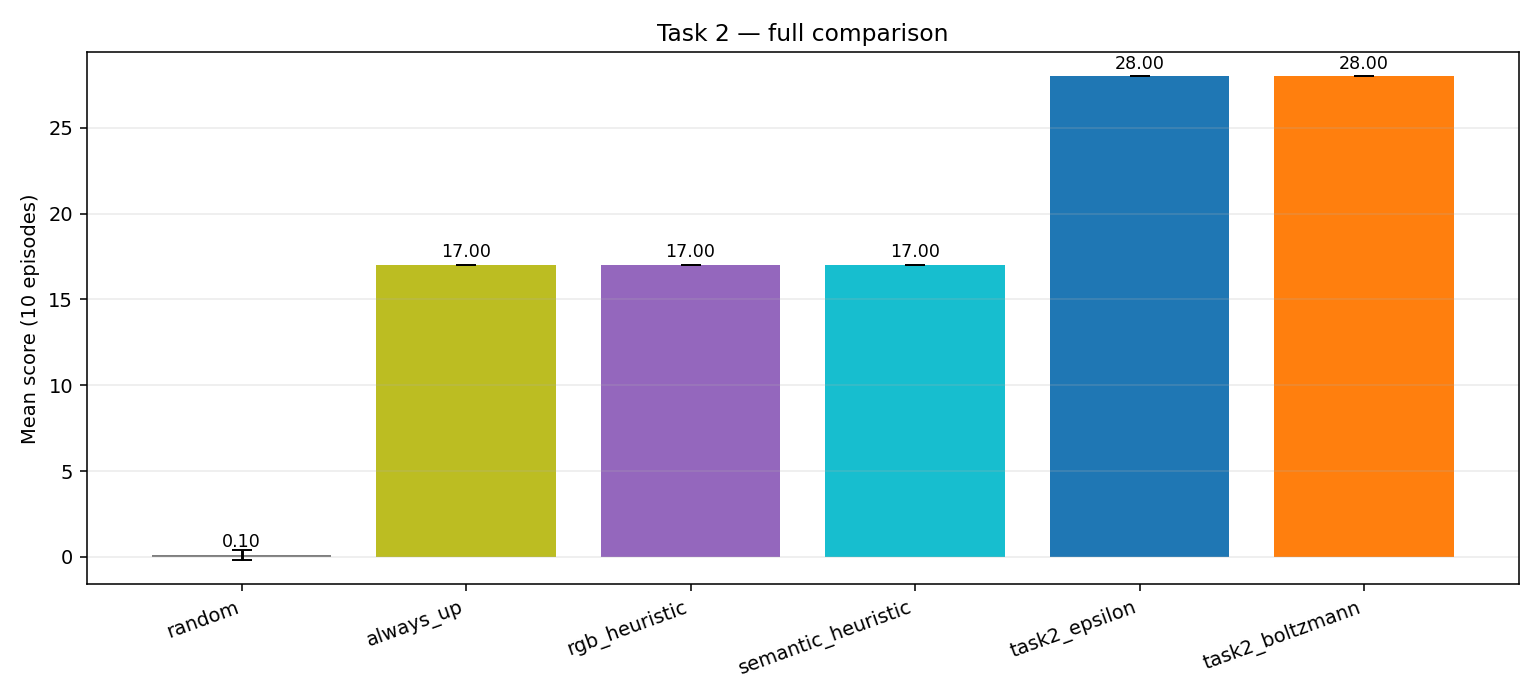

In [ ]:
labels, means, stds = [], [], []

for b in baselines:
    labels.append(b['policy']); means.append(b['mean_score']); stds.append(b['std_score'])

if RUN_EPSILON:
    labels.append('task2_epsilon'); means.append(final_eps['mean_score']); stds.append(final_eps['std_score'])
if RUN_BOLTZMANN:
    labels.append('task2_boltzmann'); means.append(final_bol['mean_score']); stds.append(final_bol['std_score'])
if RUN_PER:
    labels.append('task2_per'); means.append(final_per['mean_score']); stds.append(final_per['std_score'])

palette = ['tab:gray','tab:olive','tab:purple','tab:cyan',
           'tab:blue','tab:orange','tab:green']
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, means, yerr=stds, capsize=5,
              color=palette[:len(labels)])
for bar, m in zip(bars, means):
    ax.annotate(f'{m:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, m),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_ylabel('Mean score (10 episodes)'); ax.set_title('Task 2 — full comparison')
ax.grid(axis='y', alpha=.25); plt.xticks(rotation=20, ha='right'); plt.tight_layout()
p = DOCS_DIR / 'task2_full_comparison.png'
fig.savefig(p, dpi=140); plt.close(fig)
display(Image(filename=str(p)))

## 8 · Efficiency metrics

The assignment asks for **score / training-time** and **Q-value / training-time**.

In [ ]:
print(f"{'Variant':18s}  {'Mean score':>10}  {'Train (min)':>11}  "
      f"{'Score/min':>10}  {'MaxQ/min':>10}")
print('-' * 66)

for label, trainer, final in (
    [('ε-greedy',  trainer_eps, final_eps)] if RUN_EPSILON  else []
  + [('Boltzmann', trainer_bol, final_bol)] if RUN_BOLTZMANN else []
  + [('PER',       trainer_per, final_per)] if RUN_PER else []
):
    tm = trainer.train_minutes
    spm = final['mean_score'] / tm if tm > 0 else float('nan')
    qpm = final['mean_max_q']  / tm if tm > 0 else float('nan')
    print(f"{label:18s}  {final['mean_score']:10.2f}  {tm:11.2f}  {spm:10.3f}  {qpm:10.3f}")

Variant             Mean score  Train (min)   Score/min    MaxQ/min
------------------------------------------------------------------
ε-greedy                 28.00        23.22       1.206       0.256


## 9 · Package and verify the best agent

In [ ]:
# Pick the variant with the highest mean_score
candidates = []
if RUN_EPSILON:   candidates.append((final_eps['mean_score'], trainer_eps, cfg_eps, final_eps))
if RUN_BOLTZMANN: candidates.append((final_bol['mean_score'], trainer_bol, cfg_bol, final_bol))
if RUN_PER:       candidates.append((final_per['mean_score'], trainer_per, cfg_per, final_per))
candidates.sort(key=lambda x: x[0], reverse=True)

_, best_trainer, best_cfg, best_final = candidates[0]
print(f'Best variant: {best_cfg.submission_name}  mean={best_final["mean_score"]:.2f}')

packager = SubmissionPackager(best_cfg)
summary  = packager.package(
    best_trainer.agent,
    state_shape   = best_trainer.state_shape,
    history       = best_trainer.history,
    eval_history  = best_trainer.eval_history,
    baselines     = baselines,
    final_eval    = best_final,
    train_minutes = best_trainer.train_minutes,
)
print('ZIP:', summary['files']['zip'])

Best variant: task2_epsilon  mean=28.00
ZIP: C:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment2\submissions\task2_epsilon\submission_task2_epsilon.zip


In [ ]:
# Isolated re-evaluation — mirrors Codabench (include_semantic_info=False)
import shutil, tempfile, zipfile
zip_path = Path(summary['files']['zip'])
tmp = Path(tempfile.mkdtemp(prefix='task2_verify_'))
try:
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp)
    inf_policy = DQNInferencePolicy(tmp / 'agent.py')
    result = evaluator.run(inf_policy, n_episodes=5, include_semantic_info=False)
    print(f'Isolated re-eval (5 ep): mean={result["mean_score"]:.2f}  '
          f'std={result["std_score"]:.2f}  max={result["max_score"]:.2f}')
finally:
    shutil.rmtree(tmp, ignore_errors=True)

Isolated re-eval (5 ep): mean=28.00  std=0.00  max=28.00


In [ ]:
# Load best trained agent
test_cfg = Config2()
# Pick random, unseen seeds
test_cfg.base_eval_seed = random.randint(8000, 9000) 

evaluator = Evaluator(test_cfg)
inf_policy = DQNInferencePolicy(SUBMISSIONS_DIR / best_cfg.submission_name / 'agent.py')

print(f"Testing on 20 unseen Codabench-style seeds (Starting seed: {test_cfg.base_eval_seed})...")

# Must be include_semantic_info=False
result = evaluator.run(inf_policy, n_episodes=20, include_semantic_info=False)

print("-" * 40)
print(f"TRUE GENERALIZATION SCORE: {result['mean_score']:.2f}")
print(f"Standard Deviation:        {result['std_score']:.2f}")
print("-" * 40)

Testing on 20 unseen Codabench-style seeds (Starting seed: 8367)...
----------------------------------------
TRUE GENERALIZATION SCORE: 28.00
Standard Deviation:        0.00
----------------------------------------
